PCA Results
Original Number of Features: 33
Reduced Number of Features: 2
Explained Variance Ratio: [0.2525452  0.04971866]
Total Explained Variance: 30.23 %


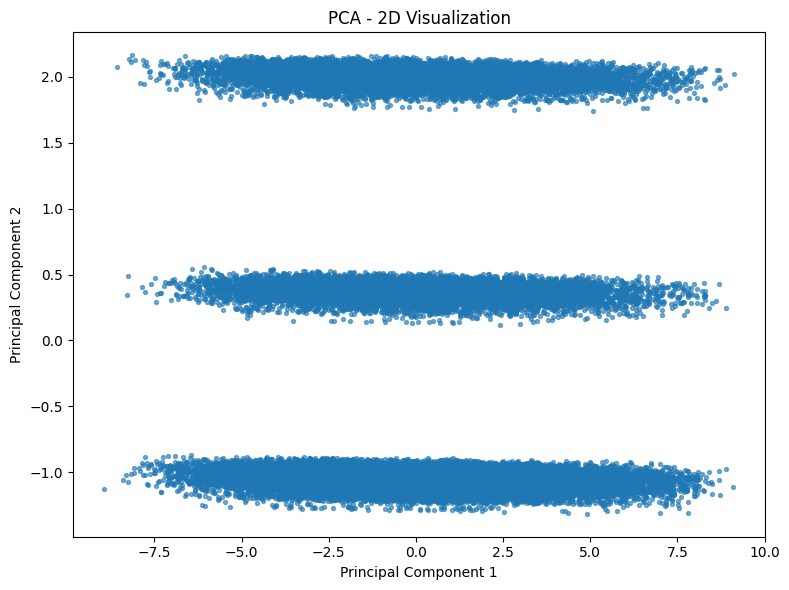

PCA completed successfully.


In [1]:
# PCA.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

NUMERIC_COLS = [
    "CGPA", "AttendancePercent", "Internships", "Projects", "Workshops",
    "Certifications", "Publications", "AptitudeTestScore",
    "SoftSkillsRating", "CodingTestScore", "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender", "City", "CollegeTier", "Stream", "Specialisation",
    "Hostel", "HistoryOfBacklogs", "ExtraCurricular"
]

df = pd.read_csv("placement_predict_50k_adjusted (1).csv")

imputer = SimpleImputer(
    strategy="median"
)

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)

cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

feature_df = pd.concat(
    [num_df, cat_df],
    axis=1
)

scaler = StandardScaler()

X = scaler.fit_transform(
    feature_df
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

print("PCA Results")
print("Original Number of Features:", X.shape[1])
print("Reduced Number of Features:", X_pca.shape[1])

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    round(
        sum(pca.explained_variance_ratio_) * 100,
        2
    ),
    "%"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization")

plt.tight_layout()

plt.savefig("pca_2d.png")

plt.show()

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.to_csv(
    "pca_result.csv",
    index=False
)

print("PCA completed successfully.")